# Lab Session 5: Grover's Algorithm

This notebook implements Grover's search algorithm, studies amplitude amplification, and explores the impact of transpilation and noise.


In [12]:
# Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit_aer.noise import NoiseModel, pauli_error


## Oracle Construction
To mark a specific state such as `00` or `10`, we flip its phase. Since a multi-controlled phase gate naturally acts on the all-ones state, we temporarily map each target state to that configuration with `X` gates, apply the phase flip, and then undo the mapping. The same pattern is repeated for every state listed in `state_list`.


In [13]:
def gen_oracle(qc, state_list):
    """
    Add an oracle to the quantum circuit to mark specified states.
    """
    num_qubits = qc.num_qubits
    
    # We do this for every state that should be marked (ex: '00', '10')
    for state in state_list:
        
        # Preparation
        # We apply a X gate on qubits corresponding to 0 in the state.

        for i, bit in enumerate(reversed(state)):
            if bit == '0':
                qc.x(i)
                
        # Marking
        # We apply a multi-control phase gate Z to multiply the amplitud by -1 when all qubits are 1.

        if num_qubits == 1:
            qc.z(0)
        else:
            controls = list(range(num_qubits - 1))
            target = num_qubits - 1
            
            qc.mcp(np.pi, controls, target)
            
        # Back to normal
        #We apply X gates where we first applied themto put qubits back in their original state.

        for i, bit in enumerate(reversed(state)):
            if bit == '0':
                qc.x(i)
                
    return qc


## Diffusion Operator
The diffusion operator amplifies the probability of the marked state by reflecting amplitudes around their average value. Its standard structure is a sequence of `H`, `X`, a multi-controlled phase flip, and then the inverse `X` and `H` layers.


In [14]:

def gen_diffusion(qc):
    """
    Applies Grover's diffusion operator to all qubits in the provided quantum circuit.
    """
    num_qubits = qc.num_qubits
    
    # We apply Hadamard gates to all qubits
    for i in range(num_qubits):
        qc.h(i)
        
    # We apply X gates to all qubits
    for i in range(num_qubits):
        qc.x(i)
        
    # We apply a Multi-Controlled Z gate
    if num_qubits == 1:
        qc.z(0)
    else:
        controls = list(range(num_qubits - 1))
        target = num_qubits - 1
        qc.mcp(np.pi, controls, target)
        
    # We apply X gates to all qubits again
    for i in range(num_qubits):
        qc.x(i)
        
    # We pply Hadamard gates to all qubits again
    for i in range(num_qubits):
        qc.h(i)
        
    return qc


## Ideal Simulation
The `ideal_sim` helper copies the circuit, adds measurements, and runs it on Qiskit's noiseless simulator so the original circuit can still be reused later in the notebook.


In [15]:
def ideal_sim(qc):
    """
    Executes the given quantum circuit on a Aer simulator without noise
    and returns the measurements.
    """
    # We create a copy so we don't alter the original circuit with the measurements
    qc_measured = qc.copy()
    qc_measured.measure_all()
    
    # We the standard simulator (without noise)
    simulator = Aer.get_backend('aer_simulator')
    
    # We transpile to ensure compatibility
    compiled_circuit = transpile(qc_measured, simulator)
    
    # WE run the circuit 
    job = simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    
    # We extract and return the counts
    counts = result.get_counts(compiled_circuit)
    return counts



For the test, we initialize 5 qubits in a full superposition then we apply our oracle to mark a chosen state and run the diffusion operator once. The resulting histogram plots the probabilities  showing an amplified peak for our targeted state

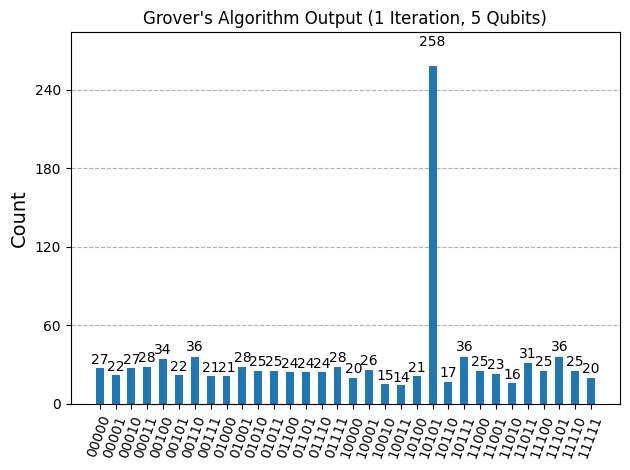

In [16]:
# TEST: Single Grover iteration on 5 qubits

n = 5
qc_grover = QuantumCircuit(n)

#Initialization : we put all qubits in a uniform superposition
for i in range(n):
    qc_grover.h(i)

#Oracle : we take for example '10101' as our secret state to find
secret_state = ['10101']
gen_oracle(qc_grover, secret_state)

#Diffusion : we amplify the probability of our secret state
gen_diffusion(qc_grover)

#Simulation and plotting
results = ideal_sim(qc_grover)
plot_histogram(results, title="Grover's Algorithm Output (1 Iteration, 5 Qubits)")
# plt.show()


## Statevector Visualization
To visualize amplitude changes directly, we build a statevector from the circuit before measurement. This makes it possible to inspect the sign flip introduced by the oracle and the amplification produced by the diffusion operator.


In [17]:
def plot_amplitudes(qc):
    """
    Calculates the exact state vector of the circuit (without measurements) and plots the amplitudes of each basis state.
    """
    # We extract the state vector from the quantum circuit
    state = Statevector(qc)
    
    #We extract the real part of the complex data array.
    amplitudes = np.real(state.data)
    
    #We generate binary labels for the x-axis based on the number of qubits
    num_qubits = qc.num_qubits
    labels = [format(i, f'0{num_qubits}b') for i in range(2**num_qubits)]
    
    #Creating the bar chart
    fig = plt.figure(figsize=(12, 6))
    plt.bar(labels, amplitudes, color='royalblue')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel('Real Amplitude')
    plt.title(f"Statevector Amplitudes ({num_qubits} qubits)")

    return fig


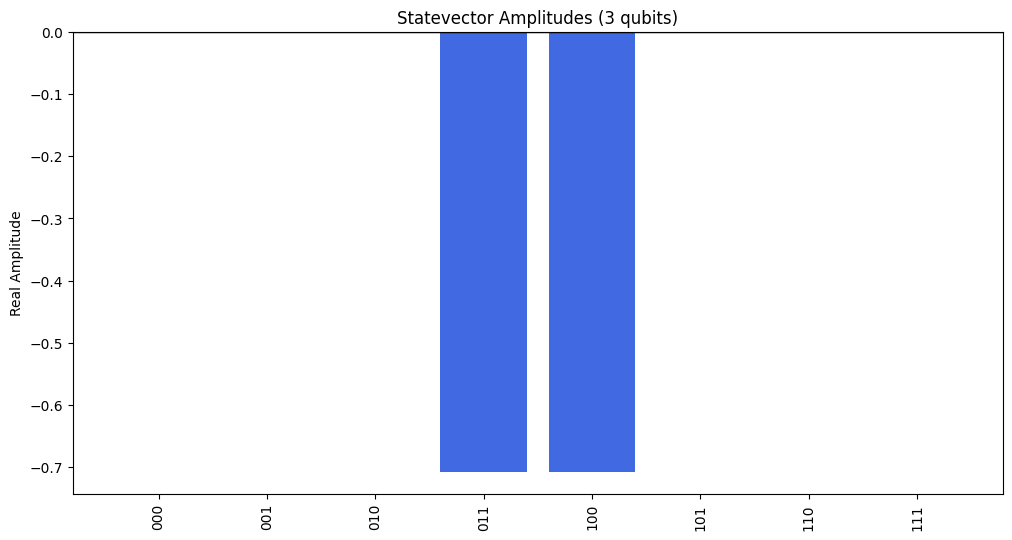

In [18]:
# TEST: Arbitrary states and qubits 


n_test = 3
qc_test = QuantumCircuit(n_test)

# Initialization
for i in range(n_test):
    qc_test.h(i)

# Oracle: marking two arbitrary states to verify the function works with a list
gen_oracle(qc_test, ['011', '100'])

# Diffusion
gen_diffusion(qc_test)

# Plot the amplitudes (No measurements added!)
fig = plot_amplitudes(qc_test)


## Overshooting Analysis
This section tracks the amplitude of the marked state as the number of Grover iterations increases, making the overshooting effect visible.


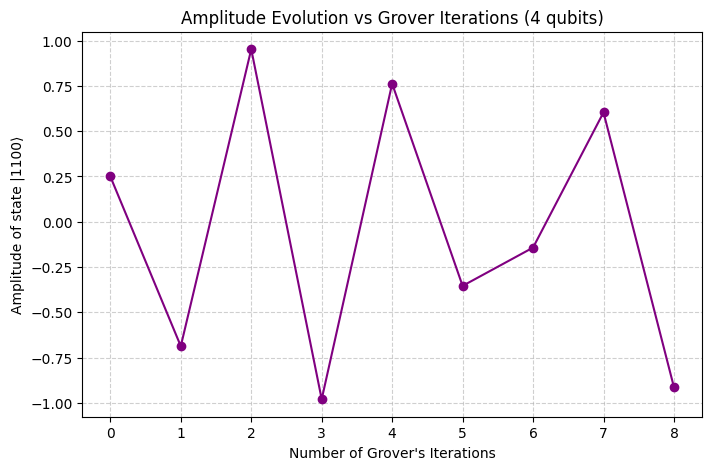

In [19]:
n_qubits = 4
# We pick an arbitrary state to search for
target_state = '1100' 
max_iterations = 8
amplitudes_over_time = []

# We test from 0 to 8 Grover iterations
for k in range(max_iterations + 1):
    qc = QuantumCircuit(n_qubits)
    
    # Initialization
    for i in range(n_qubits):
        qc.h(i)
        
    # We apply the Grover operator k times
    for _ in range(k):
        gen_oracle(qc, [target_state])
        gen_diffusion(qc)
        
    # We extract the exact state vector
    state = Statevector(qc)
    
    # Index of our target state
    target_index = int(target_state, 2)
    
    # Real amplitude
    amp = state.data[target_index].real
    amplitudes_over_time.append(amp)

fig = plt.figure(figsize=(8, 5))
plt.plot(range(max_iterations + 1), amplitudes_over_time, marker='o', color='purple')
plt.xlabel("Number of Grover's Iterations")
plt.ylabel(f"Amplitude of state |{target_state}⟩")
plt.title("Amplitude Evolution vs Grover Iterations (4 qubits)")
plt.grid(True, linestyle='--', alpha=0.6)


Looking at our plot, the amplitude reaches its absolute maximum at 3 iterations. At the 4th Grover step, the amplitude clearly begins to diminish, because the state vector has "rotated" past the optimal target axis.

## Multiple Marked States
Here the experiment is repeated with two marked states instead of one, illustrating how the dynamics change when the search space contains multiple valid targets.


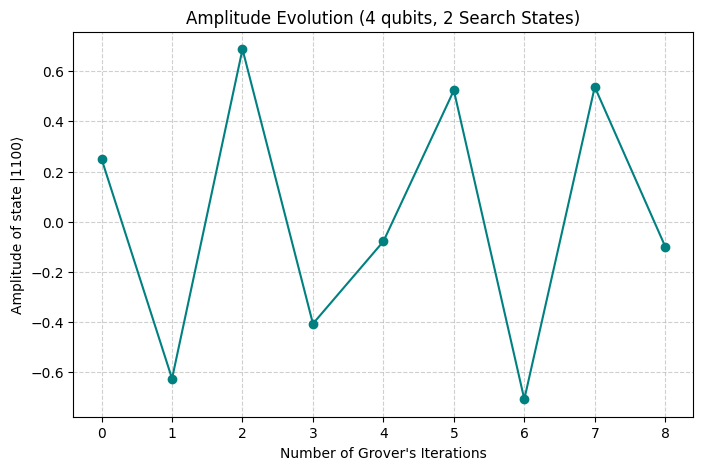

In [20]:
n_qubits = 4
# We now define two states to search for
target_states = ['1100', '0011'] 
max_iterations = 8

amplitudes_over_time = []

for k in range(max_iterations + 1):
    qc = QuantumCircuit(n_qubits)
    
    #Initialization
    for i in range(n_qubits):
        qc.h(i)
        
    #We apply the Grover operator k times
    for _ in range(k):
        # We pass both states to our oracle
        gen_oracle(qc, target_states)
        gen_diffusion(qc)
        
    state = Statevector(qc)
    
    #We only need to track the amplitude of the first one to see the trend due to simmetry.
    target_index = int(target_states[0], 2)
    amp = state.data[target_index].real
    amplitudes_over_time.append(amp)

#Results
fig = plt.figure(figsize=(8, 5))
plt.plot(range(max_iterations + 1), amplitudes_over_time, marker='o', color='teal')
plt.xlabel("Number of Grover's Iterations")
plt.ylabel(f"Amplitude of state |{target_states[0]}⟩")
plt.title("Amplitude Evolution (4 qubits, 2 Search States)")
plt.grid(True, linestyle='--', alpha=0.6)


By plotting the amplitudes for 2 target states, we observe the periodic nature of amplitude amplification. The amplitude peaks early (at 3 iterations) before overshooting and diminishing. Then it rotates back toward another peak later at the sixth iteration.

## Hardware-Aware Transpilation
The circuit is transpiled to a constrained topology and gate set. This increases the depth because multi-controlled operations must be decomposed into simpler primitives.


In [21]:

#We build a 4-qubit Grover circuit (1 iteration) for testing
n_qubits = 4
qc_ideal = QuantumCircuit(n_qubits)

for i in range(n_qubits):
    qc_ideal.h(i)
    
# Oracle and diffusion
gen_oracle(qc_ideal, ['1100'])
gen_diffusion(qc_ideal)

depth_before = qc_ideal.depth()

#Defining our hardware constraints
#0 connects to 1, 1 to 2, 2 to 3, and 3 back to 0.
# We add both directions so CNOTs can be applied either way.
my_coupling_map = [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 0], [0, 3]]

# Restricted gate set allowed by the "hardware"
my_basis_gates = ['cx', 'rz', 'rx', 'h']

#Use the transpile function 
# # The transpiler will rewrite our ideal circuit using our constraints
qc_transpiled = transpile(qc_ideal, basis_gates=my_basis_gates, coupling_map=my_coupling_map, optimization_level=3)

depth_after = qc_transpiled.depth()

print(f"Circuit depth before transpilation: {depth_before}")
print(f"Circuit depth after transpilation: {depth_after}")


Circuit depth before transpilation: 9
Circuit depth after transpilation: 108


## Noise Analysis
A Pauli error model is added to the transpiled circuit to show how accumulated noise can suppress the amplification advantage of Grover's algorithm.


In [22]:
#Defining error probabilities
p_1q = 0.02 #2% error on 1-qubit gates
p_2q = 0.05 #5% error on 2-qubit gates

#We create Pauli-X errors
error_1q = pauli_error([('X', p_1q), ('I', 1 - p_1q)])
error_2q = error_1q.tensor(error_1q) # Combine two 1-qubit errors for the CNOT

#We build the noise model
noise_model = NoiseModel()
#We add the errors to the basis gates we used in transpilation
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'rz', 'h']) [cite: 57]
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

#Preparation of the transpiled circuit for measurement
qc_noisy = qc_transpiled.copy() 
qc_noisy.measure_all()

#Running the noisy simulation
simulator = Aer.get_backend('aer_simulator')
job_noisy = simulator.run(qc_noisy, noise_model=noise_model, shots=1024)
counts_noisy = job_noisy.result().get_counts()

#Results
plot_histogram(counts_noisy, title="Noisy Grover (1 Iteration, 4 Qubits)")


NameError: name 'cite' is not defined


We built a 40-qubit circuit with 20 Grover iterations and transpiled it for a cycle topology.

Circuit Depth: The depth of this circuit will be enormous. Breaking down 40-qubit multi-controlled gates into simple CNOTs and routing them through a ring topology requires massive amounts of gates.

However it is completely impossible to run this on today's noisy quantum computers without error correction. At huge depth the noise will completely destroy the quantum state long before the 20 iterations finish. The output would just be random garbage.

In [ ]:
n_qubits = 40
iterations = 20

#We build the 40-qubit circuit
qc_40 = QuantumCircuit(n_qubits)

#Initialization
for i in range(n_qubits):
    qc_40.h(i)

#We apply 20 Grover iterations
for _ in range(iterations):
    controls = list(range(n_qubits - 1))
    target = n_qubits - 1
    qc_40.mcp(np.pi, controls, target)
    gen_diffusion(qc_40)

# We dfine the 40-qubit cycle topology
coupling_map_40 = []
for i in range(n_qubits):
    coupling_map_40.append([i, (i + 1) % n_qubits])
    coupling_map_40.append([(i + 1) % n_qubits, i])

basis_gates = ['cx', 'rz', 'rx', 'h']

#Transpile the circuit to get the depth
qc_transpiled_40 = transpile(qc_40, basis_gates=basis_gates, coupling_map=coupling_map_40, optimization_level=1)

print(f"Depth of the 40-qubit circuit: {qc_transpiled_40.depth()}")
